# IT25100430 — Kariyawasam K.H.M.M
## Preprocessing Technique: Standardization / Scaling

**Assigned dataset:** Real-World Style Fitness Classification Dataset (Synthetic)  
**Target variable:** `is_fit`  
**Assigned technique:** Standardize the numerical features so they share a common
scale before model training.

### Why this technique is needed
The numerical features in this dataset are measured on very different scales —
for example, `age` (years, roughly 18-80), `blood_pressure` (mmHg, roughly
90-180), and `nutrition_quality` (a 0-10 score). Algorithms that rely on
distance calculations or gradient-based optimization (e.g., Neural Networks,
SVM, K-Means, Logistic Regression) can be dominated by features with naturally
larger numeric ranges, even if those features are not actually more important.
Standardization (z-score scaling) rescales every numeric feature to have
**mean = 0** and **standard deviation = 1**, putting them on equal footing.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')

df = pd.read_csv('../data/raw/fitness_dataset.csv')

# Handle the missing sleep_hours values first so scaling has no NaNs to deal with
df['sleep_hours'] = df['sleep_hours'].fillna(df['sleep_hours'].mean())

numeric_cols = ['age', 'height_cm', 'weight_kg', 'heart_rate', 'blood_pressure',
                 'sleep_hours', 'nutrition_quality', 'activity_index']
df[numeric_cols].describe()


,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index
count,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,49.114000,174.53300,83.540500,70.288600,119.908850,7.513315,5.035140,2.999040
std,17.926564,14.37175,25.852534,11.846339,14.578032,1.440666,2.864156,1.136383
min,18.000000,150.00000,30.000000,45.000000,90.000000,4.000000,0.000000,1.000000
25%,34.000000,162.00000,64.000000,62.100000,109.700000,6.600000,2.547500,2.037500
50%,49.000000,174.00000,83.000000,70.250000,120.000000,7.513315,5.065000,2.980000
75%,65.000000,187.00000,102.000000,78.425000,129.800000,8.400000,7.470000,3.950000
max,79.000000,199.00000,250.000000,118.600000,171.200000,12.000000,10.000000,4.990000


Notice the very different scales above — e.g. `blood_pressure` values
are in the hundreds while `activity_index` ranges roughly 1-5.

### EDA Visualization — Correlation heatmap (BEFORE scaling)

Standardization does not change correlation structure (Pearson correlation is
scale-invariant), so the heatmap below is a valid check of relationships between
the numeric features and the target, both before and after scaling.

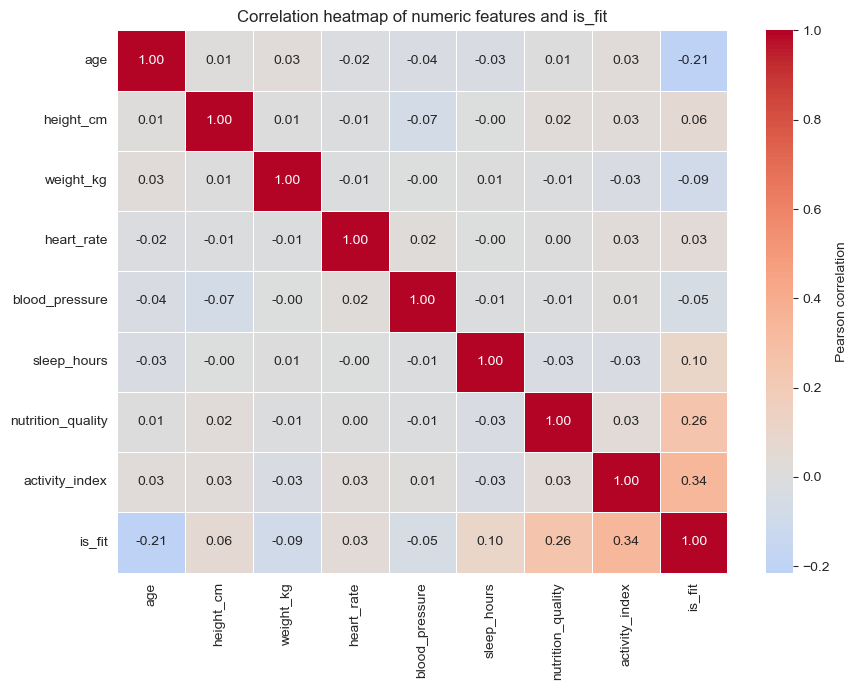

In [2]:
fig, ax = plt.subplots(figsize=(9,7))
corr = df[numeric_cols + ['is_fit']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Pearson correlation'})
ax.set_title('Correlation heatmap of numeric features and is_fit')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/member6_correlation_heatmap.png', dpi=110, bbox_inches='tight')
plt.show()


**Interpretation:** The heatmap shows generally low-to-moderate
correlations between most raw features, which is expected given the dataset was
generated with a non-linear (sigmoid-like) relationship to the target — so no
single feature dominates. `nutrition_quality` and `activity_index` show the
strongest (positive) association with `is_fit` among the raw numeric features,
consistent with the domain intuition that better nutrition and higher activity
levels relate to being fit. No pair of predictor features shows extreme
multicollinearity (e.g., > 0.85), so all numeric features can reasonably be kept
for modeling.

In [3]:
# Step 1: Apply standardization (z-score scaling)
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df_scaled[numeric_cols])

print("Means after scaling (should be ~0):")
print(df_scaled[numeric_cols].mean().round(3))
print()
print("Std devs after scaling (should be ~1):")
print(df_scaled[numeric_cols].std().round(3))


Means after scaling (should be ~0):
age                  0.0
height_cm            0.0
weight_kg            0.0
heart_rate           0.0
blood_pressure      -0.0
sleep_hours          0.0
nutrition_quality   -0.0
activity_index       0.0
dtype: float64

Std devs after scaling (should be ~1):
age                  1.0
height_cm            1.0
weight_kg            1.0
heart_rate           1.0
blood_pressure       1.0
sleep_hours          1.0
nutrition_quality    1.0
activity_index       1.0
dtype: float64


In [6]:
df_scaled[numeric_cols].describe().round(2)


,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.74,-1.71,-2.07,-2.14,-2.05,-2.44,-1.76,-1.76
25%,-0.84,-0.87,-0.76,-0.69,-0.70,-0.63,-0.87,-0.85
50%,-0.01,-0.04,-0.02,-0.00,0.01,0.00,0.01,-0.02
75%,0.89,0.87,0.71,0.69,0.68,0.62,0.85,0.84
max,1.67,1.70,6.44,4.08,3.52,3.12,1.73,1.75


**Interpretation:** After standardization, every numeric feature has a
mean of ~0 and a standard deviation of ~1, confirming the scaling worked correctly.
Crucially, standardization does not change the *shape* of each feature's
distribution or its correlation with other features/target — only its scale — so
the relationships identified in the heatmap above remain valid for the scaled data
that will feed into the group's models.

### Justification recap
- **Technique:** `StandardScaler` (z-score standardization) applied to all
  continuous numeric features.
- **Why:** The raw numeric features span very different ranges; standardizing puts
  them on equal footing so that gradient-based/distance-based models are not biased
  toward features with naturally larger magnitudes.
- **Output:** `df_scaled` — dataset with all numeric features standardized, ready
  for model training in the group pipeline.

In [7]:
df_scaled.to_csv('../results/outputs/member6_standardized.csv', index=False)
print("Saved output to results/outputs/member6_standardized.csv")


Saved output to results/outputs/member6_standardized.csv
